1 Import Libraries
2 Load Raw Datasets
3 Dataset Structure Overview
4 Year Coverage Check
5 Data Reshaping (Wide to Long Format)
6 Dataset Merging (Country-Year Level)
7 Country-Year Coverage Analysis
8 Missing Value Analysis (Pooled)
9 Preliminary Descriptive Statistics (Pooled)
9.1 Descriptive Statistics by Year
10.1 Physicians Distribution by Year
10.2 Mean Physicians Trend (2018–2022)
10.3 Distribution Analysis (Pooled 2018–2022)
10.4 Correlation Analysis (Pooled)
11 Removal of Non-Country Aggregates
12 Removal of Rows with Missing Physicians
13 Missing Values After Physician Removal
14 Predictor Missing Value Imputation (Year-wise Median)
15 Outlier Detection (Boxplots)
16 Outlier Treatment Strategy
17 Data Transformation – Log Transformation (GDP)
18 Target Variable Definition (Bottom 30% Per Year)
19 class distribution figure
20 Global Distribution of Physician Shortage(MAP)
21 Predictor Relationships with Shortage
22 Feature Selection
23 Feature Scaling (Standardization)
24 Final Dataset Verification
25 Final Model-Ready Dataset Preview (Pooled)
26 data search by country
27 dataset save to a csv file

In [3]:
# ------------------------------------------
# 1. Import Libraries
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry
import seaborn as sns
import plotly.express as px

print("Environment Ready.")

Environment Ready.


In [4]:
# ------------------------------------------
# 2. Load Raw Datasets
# ------------------------------------------

df_physicians = pd.read_csv("../data/physicians.csv", skiprows=4)
df_gdp = pd.read_csv("../data/GDP.csv", skiprows=4)
df_health = pd.read_csv("../data/health_expenditure.csv", skiprows=4)
df_population = pd.read_csv("../data/population_growth.csv", skiprows=4)
df_school = pd.read_csv("../data/school_enrollment.csv", skiprows=4)
df_unemployment = pd.read_csv("../data/unemployment.csv", skiprows=4)
df_urban = pd.read_csv("../data/urban_population.csv", skiprows=4)

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


In [5]:
# ------------------------------------------
# 3. Dataset Structure Overview
# ------------------------------------------

datasets = {
    "physicians": df_physicians,
    "gdp": df_gdp,
    "health_expenditure": df_health,
    "population_growth": df_population,
    "school_enrollment": df_school,
    "unemployment": df_unemployment,
    "urban_population": df_urban
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info)
    print(df.shape)


PHYSICIANS
<bound method DataFrame.info of                     Country Name Country Code                 Indicator Name  \
0                          Aruba          ABW  Physicians (per 1,000 people)   
1    Africa Eastern and Southern          AFE  Physicians (per 1,000 people)   
2                    Afghanistan          AFG  Physicians (per 1,000 people)   
3     Africa Western and Central          AFW  Physicians (per 1,000 people)   
4                         Angola          AGO  Physicians (per 1,000 people)   
..                           ...          ...                            ...   
261                       Kosovo          XKX  Physicians (per 1,000 people)   
262                  Yemen, Rep.          YEM  Physicians (per 1,000 people)   
263                 South Africa          ZAF  Physicians (per 1,000 people)   
264                       Zambia          ZMB  Physicians (per 1,000 people)   
265                     Zimbabwe          ZWE  Physicians (per 1,000 people)

In [6]:
# ------------------------------------------
# Missing Physician Data by Year
# ------------------------------------------

# Identify year columns
year_columns = [col for col in df_physicians.columns if col.isdigit()]

# Count missing physician values for each year
missing_by_year = df_physicians[year_columns].isna().sum()

# Display result
print("Missing Physician Data by Year:")
print(missing_by_year)

Missing Physician Data by Year:
1960    129
1961    248
1962    250
1963    250
1964    250
       ... 
2020    130
2021    143
2022     94
2023    208
2024    266
Length: 65, dtype: int64


In [7]:
# ------------------------------------------
# 4. Year Coverage Check
# ------------------------------------------

years = ["2018", "2019", "2020", "2021", "2022"]

for year in years:
    print(year, "in physicians:", year in df_physicians.columns)

2018 in physicians: True
2019 in physicians: True
2020 in physicians: True
2021 in physicians: True
2022 in physicians: True


In [8]:
# ------------------------------------------
# 5. Data Reshaping (Wide to Long Format)
# ------------------------------------------

years = ["2018", "2019", "2020", "2021", "2022"]

def reshape_long(df, value_name):
    return df.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=years,
        var_name="Year",
        value_name=value_name
    )

df_phys_long = reshape_long(df_physicians, "physicians")
df_gdp_long = reshape_long(df_gdp, "gdp")
df_health_long = reshape_long(df_health, "health_expenditure")
df_population_long = reshape_long(df_population, "population_growth")
df_school_long = reshape_long(df_school, "school_enrollment")
df_unemployment_long = reshape_long(df_unemployment, "unemployment")
df_urban_long = reshape_long(df_urban, "urban_population")

print("Reshaping completed.")

print("Physicians Long Shape:", df_phys_long.shape)
print("GDP Long Shape:", df_gdp_long.shape)
print("Health Expenditure Long Shape:", df_health_long.shape)
print("Population Long Shape:", df_population_long.shape)
print("School Enrollment Long Shape:", df_school_long.shape)
print("Unemployment Long Shape:", df_unemployment_long.shape)
print("Urban Population Long Shape:", df_urban_long.shape)

Reshaping completed.
Physicians Long Shape: (1330, 4)
GDP Long Shape: (1330, 4)
Health Expenditure Long Shape: (1330, 4)
Population Long Shape: (1330, 4)
School Enrollment Long Shape: (1330, 4)
Unemployment Long Shape: (1330, 4)
Urban Population Long Shape: (1330, 4)


In [9]:
# ------------------------------------------
# 6. Dataset Merging (Country-Year Level)
# ------------------------------------------

df_pooled = df_phys_long.merge(
    df_gdp_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
).merge(
    df_health_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
).merge(
    df_population_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
).merge(
    df_school_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
).merge(
    df_unemployment_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
).merge(
    df_urban_long,
    on=["Country Name", "Country Code", "Year"],
    how="left"
)

print("Merged Pooled Dataset Shape:", df_pooled.shape)
df_pooled.head()

Merged Pooled Dataset Shape: (1330, 10)


,Country Name,Country Code,Year,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population
0,Aruba,ABW,2018,NaN,3.276188e+09,NaN,0.158976,NaN,NaN,62.536764
1,Africa Eastern and Southern,AFE,2018,NaN,1.020956e+12,5.730629,2.734263,8.75093,7.244843,35.714718
2,Afghanistan,AFG,2018,0.303,1.805322e+10,14.208419,2.910810,9.99592,11.192000,24.999165
3,Africa Western and Central,AFW,2018,NaN,7.778403e+11,3.288622,2.533621,9.58899,4.334377,49.317948
4,Angola,AGO,2018,0.211,8.951279e+10,2.298875,3.453233,NaN,16.602000,65.873214


In [10]:
# ------------------------------------------
# 7. Country-Year Coverage Analysis
# ------------------------------------------

print("Unique Countries:", df_pooled["Country Name"].nunique())
print("Unique Years:", df_pooled["Year"].nunique())
print("Total Observations:", df_pooled.shape[0])

Unique Countries: 266
Unique Years: 5
Total Observations: 1330


In [11]:
# ------------------------------------------
# 8. Missing Value Analysis (Pooled)
# ------------------------------------------

missing_summary = df_pooled.isnull().sum().sort_values(ascending=False)

print("Missing Values Across Pooled Dataset:")
print(missing_summary)

Missing Values Across Pooled Dataset:
physicians            607
school_enrollment     471
unemployment          156
health_expenditure    126
gdp                    39
population_growth       6
urban_population        5
Country Name            0
Country Code            0
Year                    0
dtype: int64


In [12]:
# ------------------------------------------
# 9. Preliminary Descriptive Statistics (Pooled)
# ------------------------------------------

df_pooled.describe()

,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population
count,723.000000,1.291000e+03,1204.000000,1324.000000,859.000000,1174.000000,1325.000000
mean,2.175321,2.952431e+12,6.724502,1.034387,49.039858,7.417200,60.687191
std,1.790746,1.006426e+13,3.103751,1.396488,28.934057,5.326075,22.307743
min,0.022000,4.801526e+07,1.755850,-10.927442,1.694240,0.100000,13.712572
25%,0.423000,1.027615e+10,4.458974,0.217766,23.590950,4.046750,42.615514
50%,2.087000,6.038289e+10,5.979265,1.017249,50.235571,5.847181,61.114927
75%,3.482500,6.042990e+11,8.442802,1.970099,72.297741,9.079970,78.932401
max,9.542000,1.022515e+14,23.088169,5.907018,166.665649,36.472000,100.000000


In [13]:
# ------------------------------------------
# 9.1 Descriptive Statistics by Year
# ------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df_pooled.groupby("Year")[[
    "physicians",
    "gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]].describe()

physicians                                                              \
          count      mean       std    min       25%     50%     75%    max   
Year                                                                          
2018      157.0  2.005261  1.772948  0.037  0.363000  1.8140  3.2360  8.505   
2019      135.0  2.244319  1.839193  0.033  0.616500  2.2350  3.4880  8.677   
2020      136.0  2.229132  1.823049  0.035  0.548750  2.2280  3.5090  9.291   
2021      123.0  2.391073  1.814706  0.022  0.619000  2.5170  3.6595  9.542   
2022      172.0  2.079558  1.724159  0.028  0.285183  1.9275  3.5005  6.598   

        gdp                                                          \
      count          mean           std           min           25%   
Year                                                                  
2018  259.0  2.763906e+12  9.447837e+12  4.801526e+07  9.961398e+09   
2019  259.0  2.815728e+12  9.599437e+12  5.412320e+07  1.019058e+10   
2020  258.0  2.740336e+12  9.370977e+12  5.174659e+07  9.564426e+09   
2021  258.0  3.149174e+12  1.071027e+13  6.019641e+07  1.032321e+10   
2022  257.0  3.295601e+12  1.113559e+13  5.906598e+07  1.242906e+10   

                                               health_expenditure            \
               50%           75%           max              count      mean   
Year                                                                          
2018  5.852248e+10  5.461441e+11  8.705096e+13              241.0  6.325645   
2019  6.102673e+10  5.733302e+11  8.848326e+13              241.0  6.447782   
2020  5.471669e+10  5.850065e+11  8.591276e+13              241.0  7.050702   
2021  6.211398e+10  6.260569e+11  9.814048e+13              241.0  7.051111   
2022  7.059411e+10  6.469503e+11  1.022515e+14              240.0  6.747365   

                                                                   \
           std       min       25%       50%       75%        max   
Year                                                                
2018  2.855532  1.755850  4.272624  5.547269  7.860489  18.421999   
2019  3.109647  2.127126  4.282293  5.666421  8.135418  22.222940   
2020  3.088569  2.059652  4.870713  6.209597  8.969958  18.515974   
2021  3.136177  2.147487  4.858866  6.441135  8.941903  21.508444   
2022  3.268229  1.770422  4.386774  5.952799  8.470772  23.088169   

     population_growth                                                     \
                 count      mean       std        min       25%       50%   
Year                                                                        
2018             265.0  1.151313  1.334549  -3.586045  0.345943  1.161645   
2019             265.0  1.117353  1.322092  -4.966942  0.347875  1.053292   
2020             265.0  1.030370  1.357928  -7.515685  0.196606  0.973439   
2021             265.0  0.847787  1.504379 -10.927442  0.152478  0.847680   
2022             264.0  1.025077  1.445411  -7.619320  0.205076  0.957736   

                         school_enrollment                                  \
           75%       max             count       mean        std       min   
Year                                                                         
2018  2.001422  5.815523             178.0  46.109556  28.664834  1.694240   
2019  1.984557  4.893168             176.0  46.734084  28.369765  2.855889   
2020  1.995493  5.725715             176.0  47.965676  28.656020  2.402174   
2021  1.875971  3.657200             168.0  51.405964  29.351631  2.397980   
2022  1.966609  5.907018             161.0  53.505448  29.327914  2.708137   

                                                  unemployment            \
            25%        50%        75%         max        count      mean   
Year                                                                       
2018  20.311055  46.020989  69.348101  140.950317        235.0  7.200791   
2019  22.006399  46.820375  70.290989  143.962723        235.0  7.05253

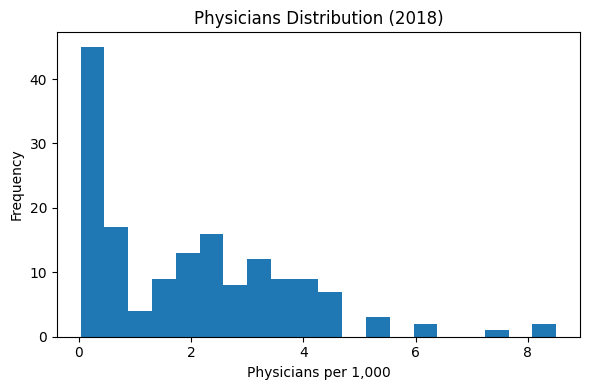

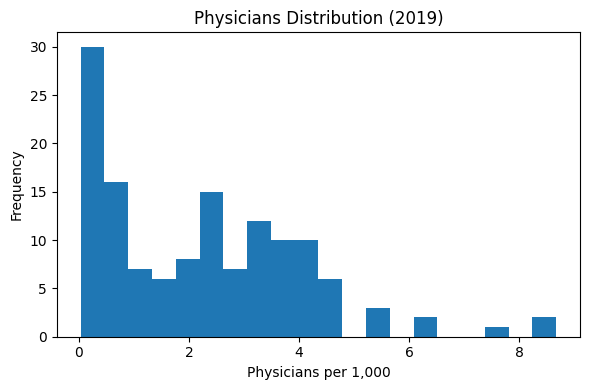

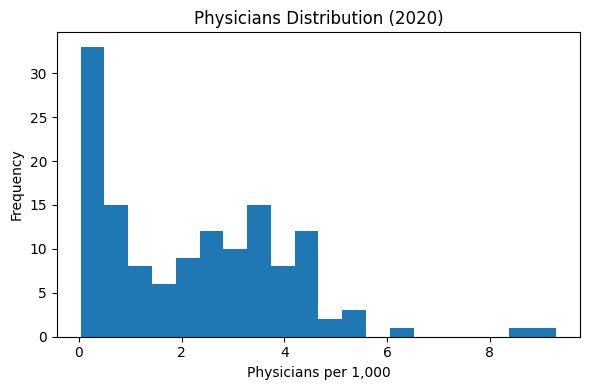

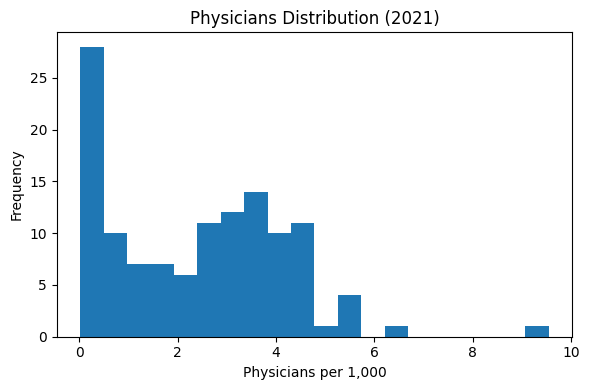

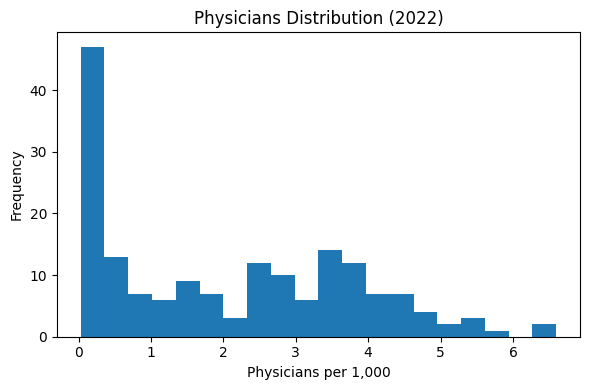

In [14]:
# ------------------------------------------
# 10.1 Physicians Distribution by Year
# ------------------------------------------


for year in df_pooled["Year"].unique():
    plt.figure(figsize=(6,4))
    subset = df_pooled[df_pooled["Year"] == year]
    plt.hist(subset["physicians"], bins=20)
    plt.title(f"Physicians Distribution ({year})")
    plt.xlabel("Physicians per 1,000")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

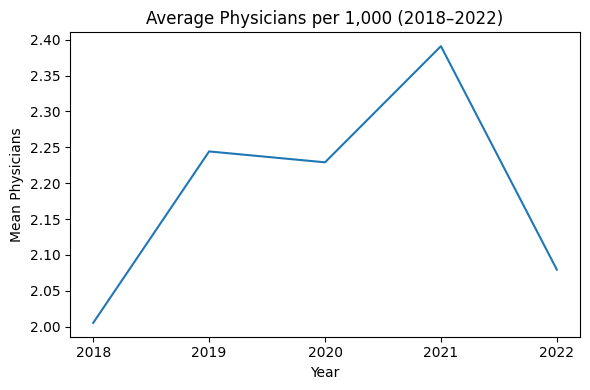

In [15]:
# ------------------------------------------
# 10.2 Mean Physicians Trend (2018–2022)
# ------------------------------------------

mean_trend = df_pooled.groupby("Year")["physicians"].mean()

plt.figure(figsize=(6,4))
plt.plot(mean_trend.index, mean_trend.values)
plt.title("Average Physicians per 1,000 (2018–2022)")
plt.xlabel("Year")
plt.ylabel("Mean Physicians")
plt.tight_layout()
plt.show()

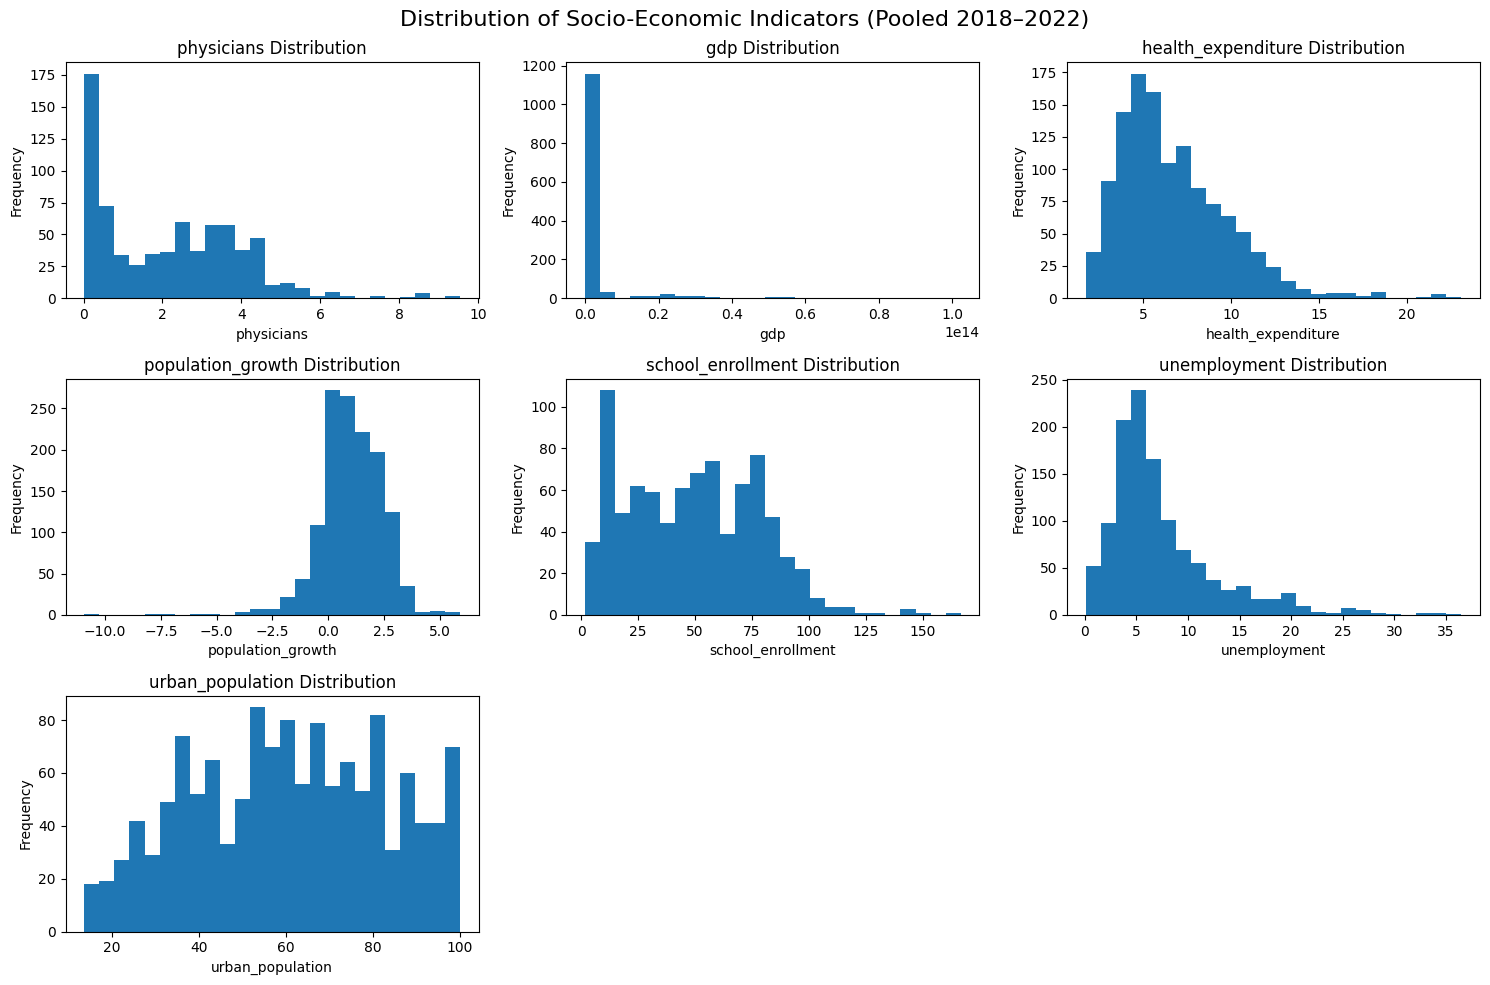

In [16]:
# -------------------------------------------------
# 10.3 Distribution Analysis (Pooled 2018–2022)
# -------------------------------------------------

variables = [
    "physicians",
    "gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].hist(df_pooled[var], bins=25)
    axes[i].set_title(f"{var} Distribution")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frequency")

# remove empty subplot spaces
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Socio-Economic Indicators (Pooled 2018–2022)", fontsize=16)
plt.tight_layout()
plt.show()

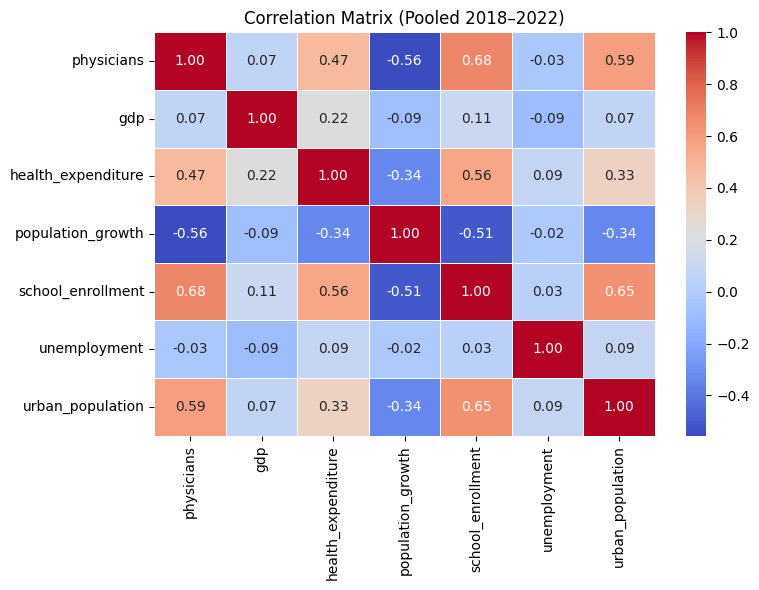

In [17]:
# ------------------------------------------
# 10.4 Correlation Analysis (Pooled)
# ------------------------------------------

corr_matrix = df_pooled[variables].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,        # shows the numbers
    cmap="coolwarm",
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix (Pooled 2018–2022)")
plt.tight_layout()
plt.show()

In [18]:
# ------------------------------------------
# 11. Removal of Non-Country Aggregates
# ------------------------------------------

valid_countries = {country.name for country in pycountry.countries}

before_rows = df_pooled.shape[0]

df_pooled = df_pooled[df_pooled["Country Name"].isin(valid_countries)]

after_rows = df_pooled.shape[0]

print("Rows before removal:", before_rows)
print("Rows after removal:", after_rows)
print("Rows removed:", before_rows - after_rows)
print("Remaining countries:", df_pooled["Country Name"].nunique())

Rows before removal: 1330
Rows after removal: 920
Rows removed: 410
Remaining countries: 184


In [19]:
# ------------------------------------------
# 12. Removal of Rows with Missing Physicians
# ------------------------------------------

before_phys = df_pooled.shape[0]

df_pooled = df_pooled[df_pooled["physicians"].notnull()]

after_phys = df_pooled.shape[0]

print("Rows before removing missing physicians:", before_phys)
print("Rows after removing missing physicians:", after_phys)
print("Rows removed:", before_phys - after_phys)
print("Remaining countries:", df_pooled["Country Name"].nunique())
print("Remaining observations:", df_pooled.shape[0])

Rows before removing missing physicians: 920
Rows after removing missing physicians: 612
Rows removed: 308
Remaining countries: 159
Remaining observations: 612


In [20]:
# ------------------------------------------
# 13. Missing Values After Physician Removal
# ------------------------------------------

missing_after_phys = df_pooled.isnull().sum().sort_values(ascending=False)

print("Remaining Missing Values:")
print(missing_after_phys)

Remaining Missing Values:
school_enrollment     163
unemployment           21
gdp                    10
population_growth       1
Country Code            0
Country Name            0
health_expenditure      0
physicians              0
Year                    0
urban_population        0
dtype: int64


In [21]:
# ------------------------------------------
# 14. Predictor Missing Value Imputation (Year-wise Median)
# ------------------------------------------

predictors = [
    "gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

for col in predictors:
    df_pooled[col] = df_pooled.groupby("Year")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Imputation completed.")

print("Missing After Imputation:")
print(df_pooled.isnull().sum())

Imputation completed.
Missing After Imputation:
Country Name          0
Country Code          0
Year                  0
physicians            0
gdp                   0
health_expenditure    0
population_growth     0
school_enrollment     0
unemployment          0
urban_population      0
dtype: int64


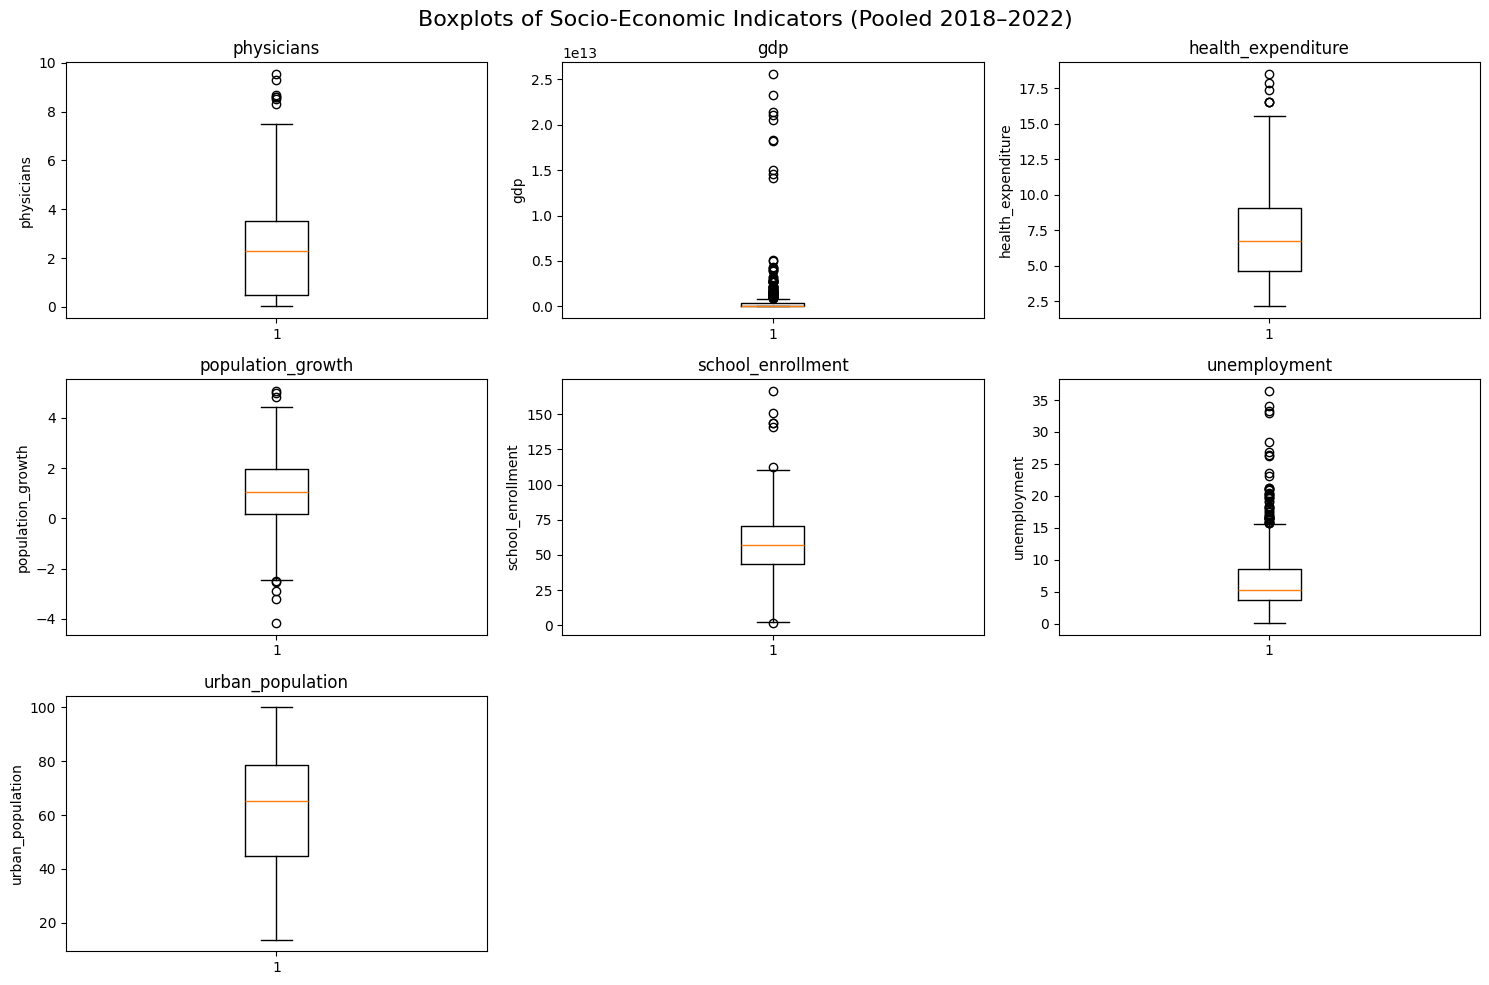

In [22]:
# -------------------------------------------------
# 15. Outlier Detection (Boxplots)
# -------------------------------------------------

variables = [
    "physicians",
    "gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, var in enumerate(variables):
    
    axes[i].boxplot(df_pooled[var], vert=True)
    
    axes[i].set_title(f"{var}")
    axes[i].set_ylabel(var)

# remove empty subplot spaces
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Socio-Economic Indicators (Pooled 2018–2022)", fontsize=16)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 16. Outlier Treatment Strategy
# ------------------------------------------

# Based on distribution analysis, extreme values represent structural economic and demographic disparities rather than measurement errors.

# Therefore, no country-year observations were removed.

In [23]:
# ------------------------------------------
# 17. Data Transformation – Log Transformation (GDP)
# ------------------------------------------
from scipy.stats import skew

df_pooled["log_gdp"] = np.log1p(df_pooled["gdp"])

print("Log transformation applied to GDP.")

original_skew = skew(df_pooled["gdp"])
log_skew = skew(df_pooled["log_gdp"])

print("Original GDP Skewness:", round(original_skew, 3))
print("Log GDP Skewness:", round(log_skew, 3))

Log transformation applied to GDP.
Original GDP Skewness: 7.158
Log GDP Skewness: 0.002


In [24]:
# ------------------------------------------
# 18. Target Variable Definition (Bottom 30% Per Year)
# ------------------------------------------

df_pooled["shortage"] = 0

for year in df_pooled["Year"].unique():
    
    threshold = df_pooled[df_pooled["Year"] == year]["physicians"].quantile(0.30)
    
    df_pooled.loc[
        (df_pooled["Year"] == year) &
        (df_pooled["physicians"] <= threshold),
        "shortage"
    ] = 1

print("Shortage label created.")

print("Overall Class Distribution:")
print(df_pooled["shortage"].value_counts())

print("\nClass Percentage:")
print(df_pooled["shortage"].value_counts(normalize=True) * 100)


print("\nClass Distribution by Year:")
print(df_pooled.groupby("Year")["shortage"].value_counts())

Shortage label created.
Overall Class Distribution:
shortage
0    427
1    185
Name: count, dtype: int64

Class Percentage:
shortage
0    69.771242
1    30.228758
Name: proportion, dtype: float64

Class Distribution by Year:
Year  shortage
2018  0           99
      1           43
2019  0           85
      1           37
2020  0           86
      1           37
2021  0           78
      1           34
2022  0           79
      1           34
Name: count, dtype: int64


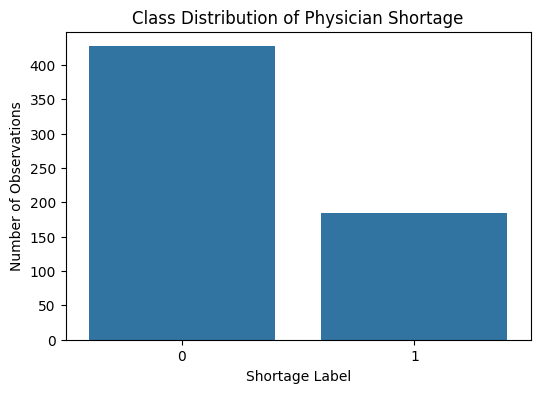

In [25]:
# ------------------------------------------
# 19. class distribution figure
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="shortage", data=df_pooled)
plt.title("Class Distribution of Physician Shortage")
plt.xlabel("Shortage Label")
plt.ylabel("Number of Observations")
plt.show()

In [26]:
# -----------------------------------------------
# 20 Global Distribution of Physician Shortage(MAP)
# -----------------------------------------------
fig = px.choropleth(
    df_pooled,
    locations="Country Code",
    color="shortage",
    hover_name="Country Name",
    animation_frame="Year",
    color_continuous_scale=["lightblue","red"],
    title="Countries at Risk of Physician Shortage (2018–2022)"
)

fig.show()

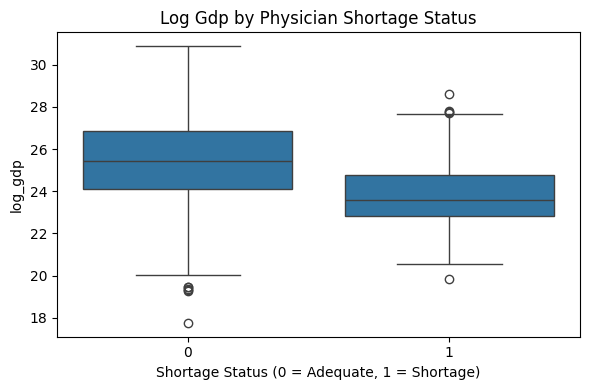

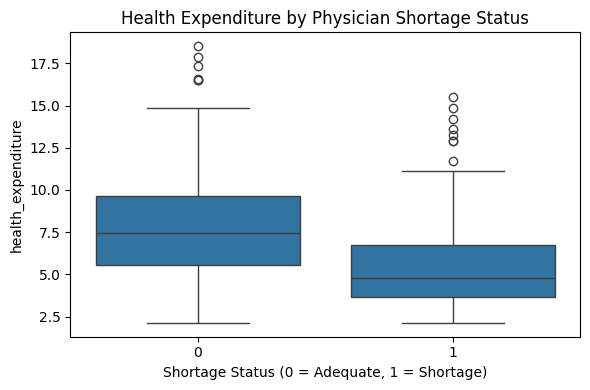

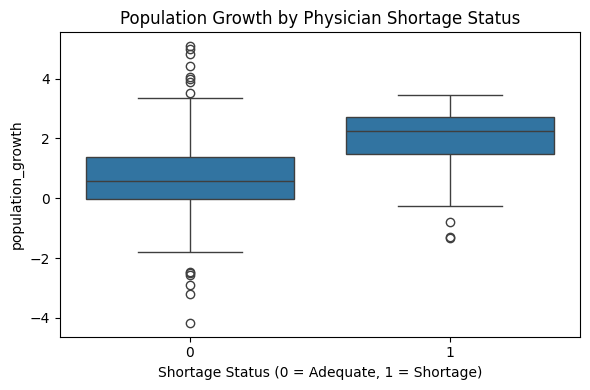

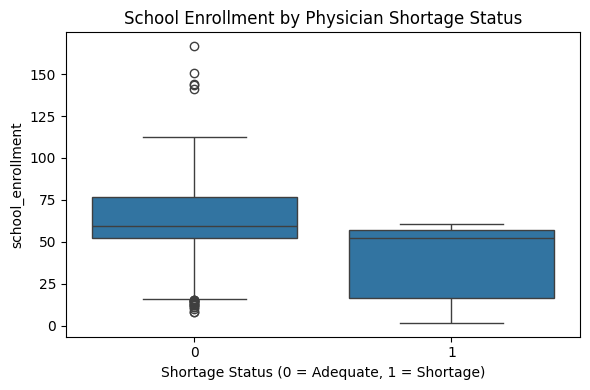

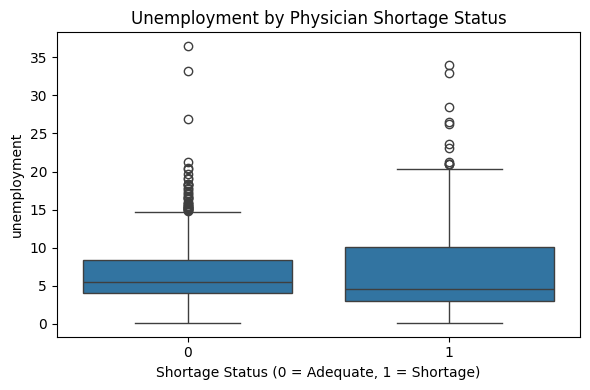

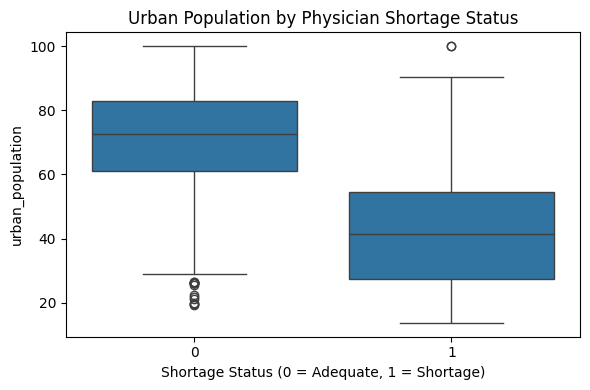

In [27]:
# ------------------------------------------
# 21.  Predictor Relationships with Shortage
# ------------------------------------------

features = [
"log_gdp",
"health_expenditure",
"population_growth",
"school_enrollment",
"unemployment",
"urban_population"
]

for var in features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x="shortage", y=var, data=df_pooled)
    
    plt.title(f"{var.replace('_',' ').title()} by Physician Shortage Status")
    plt.xlabel("Shortage Status (0 = Adequate, 1 = Shortage)")
    plt.ylabel(var)
    
    plt.tight_layout()
    plt.show()

In [28]:
# ------------------------------------------
# 22. Feature Selection
# ------------------------------------------

target = "shortage"

features = [
    "log_gdp",
    "health_expenditure",
    "population_growth",
    "school_enrollment",
    "unemployment",
    "urban_population"
]

print("Selected Features:")
print(features)

Selected Features:
['log_gdp', 'health_expenditure', 'population_growth', 'school_enrollment', 'unemployment', 'urban_population']


In [29]:
# ------------------------------------------
# 23. Feature Scaling (Standardization)
# ------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_pooled_scaled = df_pooled.copy()

df_pooled_scaled[features] = scaler.fit_transform(df_pooled[features])

print("Feature scaling completed.")

Feature scaling completed.


In [30]:
# ------------------------------------------
# 23.1 Save the Fitted Scaler for Deployment
# ------------------------------------------

import joblib

joblib.dump(scaler, "../models/scaler.joblib")

print("Scaler saved successfully.")
print("Mean values used for scaling:", dict(zip(features, scaler.mean_)))
print("Std values used for scaling:", dict(zip(features, scaler.scale_)))

Scaler saved successfully.
Mean values used for scaling: {'log_gdp': np.float64(24.948975404903596), 'health_expenditure': np.float64(7.062210919869281), 'population_growth': np.float64(1.0786073925506148), 'school_enrollment': np.float64(55.21000065092247), 'unemployment': np.float64(7.049895424836602), 'urban_population': np.float64(61.75428123204563)}
Std values used for scaling: {'log_gdp': np.float64(2.2055486295931273), 'health_expenditure': np.float64(2.9380444431360155), 'population_growth': np.float64(1.2628916433884696), 'school_enrollment': np.float64(25.07839559377911), 'unemployment': np.float64(5.302858822606482), 'urban_population': np.float64(21.835919020064495)}


In [31]:
# ------------------------------------------
# 24. Final Dataset Verification
# ------------------------------------------

print("Final Dataset Shape:", df_pooled_scaled.shape)

print("\nMissing Values Check:")
print(df_pooled_scaled.isnull().sum())

print("\nClass Distribution:")
print(df_pooled_scaled["shortage"].value_counts())

print("\nClass Percentage:")
print(df_pooled_scaled["shortage"].value_counts(normalize=True) * 100)

Final Dataset Shape: (612, 12)

Missing Values Check:
Country Name          0
Country Code          0
Year                  0
physicians            0
gdp                   0
health_expenditure    0
population_growth     0
school_enrollment     0
unemployment          0
urban_population      0
log_gdp               0
shortage              0
dtype: int64

Class Distribution:
shortage
0    427
1    185
Name: count, dtype: int64

Class Percentage:
shortage
0    69.771242
1    30.228758
Name: proportion, dtype: float64


In [32]:
# ------------------------------------------
# 25. Final Model-Ready Dataset Preview (Pooled)
# ------------------------------------------

df_pooled_scaled.sample(20, random_state=42)

,Country Name,Country Code,Year,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population,log_gdp,shortage
152,Maldives,MDV,2018,1.862,5.404344e+09,0.078905,1.664669,-0.113628,-0.393730,-1.010351,-1.150964,0
437,Namibia,NAM,2019,0.368,1.254193e+10,0.611239,1.362520,-1.168869,2.428710,-0.629802,-0.769256,1
92,Guatemala,GTM,2018,0.363,7.332836e+10,-0.325245,0.465135,-0.113628,-0.898929,-0.362170,0.031393,1
1288,Eswatini,SWZ,2022,0.561,4.746660e+09,0.062185,-0.049410,0.207702,5.548348,-1.665036,-1.209798,0
534,Afghanistan,AFG,2020,0.253,1.995593e+10,2.883348,1.643056,-1.768679,0.878791,-1.671195,-0.558674,1
287,Bulgaria,BGR,2019,4.236,6.850773e+10,0.019035,-1.971924,1.177919,-0.547232,0.547811,0.000561,0
1027,Chad,TCD,2021,0.056,1.687194e+10,-1.051712,1.873186,0.123848,-1.040928,-1.672614,-0.634789,1
647,Israel,ISR,2020,3.567,4.107684e+11,0.233423,0.542463,0.048537,-0.543272,1.365849,0.812641,0
1250,Peru,PER,2022,1.649,2.460656e+11,-0.328364,-0.094564,0.207702,-0.520266,1.035545,0.580304,0
580,Costa Rica,CRI,2020,2.494,6.239561e+10,0.259780,-0.305341,0.073966,1.769254,0.722061,-0.041810,0


In [33]:
# ------------------------------------------
# 26. data search by country
# ------------------------------------------
df_pooled[df_pooled["Country Name"] == "Comoros"].sort_values("Year")

,Country Name,Country Code,Year,physicians,gdp,health_expenditure,population_growth,school_enrollment,unemployment,urban_population,log_gdp,shortage
46,Comoros,COM,2018,0.285,1.178531e+09,4.903186,1.952742,52.360390,3.975,31.407365,20.887534,1
578,Comoros,COM,2020,0.441,1.218764e+09,5.902421,1.961994,57.064958,4.468,32.063807,20.921103,1
1110,Comoros,COM,2022,0.424,1.222486e+09,8.471195,1.938377,60.418823,3.879,32.774604,20.924152,0


In [34]:
# ------------------------------------------
# 27. dataset save to a csv file
# ------------------------------------------
df_pooled_scaled.to_csv("final_dataset_model_ready.csv", index=False)